## Genomics

Zoe Tankersley nab9pr

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

mse = lambda y_true, y_pred: np.mean((y_true - y_pred) ** 2)


Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

In [14]:
df=pd.read_csv("/content/undergrad_ml_assignments/data/golub.csv")
mapper = {'allB': 0, 'allT': 0, 'aml': 1}
df['outcome'] = df['cancer'].map(mapper)

df[['Samples', 'cancer', 'outcome']].head()

,Samples,cancer,outcome
0,39,allB,0
1,40,allB,0
2,42,allB,0
3,47,allB,0
4,48,allB,0


In [15]:
y = df['outcome']
X = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'outcome'], axis=1)

print(f'Observations: {X.shape[0]}')
print(f'Genes used as predictors: {X.shape[1]}')

Observations: 72
Genes used as predictors: 7129


2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

In [16]:
ols = LinearRegression().fit(X, y)
y_hat_ols = ols.predict(X)
residuals_ols = y_hat_ols - y

print(f'OLS training MSE: {mse(y, y_hat_ols):.6g}')

OLS training MSE: 1.25228e-30


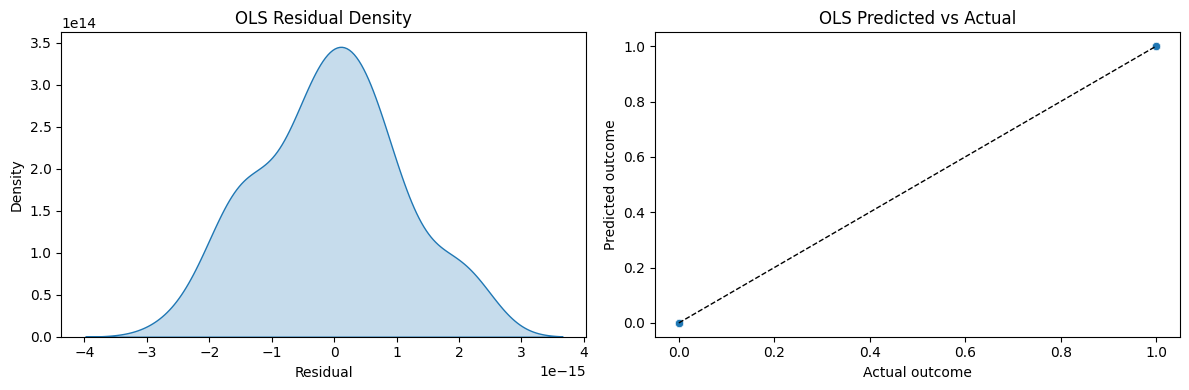

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(residuals_ols, fill=True, ax=axes[0])
axes[0].set_title('OLS Residual Density')
axes[0].set_xlabel('Residual')

sns.scatterplot(x=y, y=y_hat_ols, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
axes[1].set_title('OLS Predicted vs Actual')
axes[1].set_xlabel('Actual outcome')
axes[1].set_ylabel('Predicted outcome')

plt.tight_layout()
plt.show()

The training MSE is very close to zero, meaning that the model fits the training data almost perfectly.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

In [18]:
kfold = KFold(n_splits=5, shuffle=True, random_state=100)
cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)
cv_mse = -cv_scores

print('Fold MSE values:', cv_mse)
print(f'Mean CV MSE: {cv_mse.mean():.6f}')
print(f'Median CV MSE: {np.median(cv_mse):.6f}')
print(f'Standard deviation: {cv_mse.std():.6f}')

Fold MSE values: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean CV MSE: 0.043366
Median CV MSE: 0.024420
Standard deviation: 0.028108


The cross-validated MSE is about 0.043, which is much higher than the almost zero training MSE. This shows that the model is overfitting the training data. It fits the training set extremely well, but doesn’t perform as well on new data. This is a sign of high variance: the model is too complex and is picking up noise, especially since it is using thousands of genes but only 72 patients. As a result, the model’s near-perfect training performance is misleading and doesn’t generalize well.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

In [19]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

alpha_grid = np.logspace(-4, -2, num=50)
lasso_cv = LassoCV(cv=10, alphas=alpha_grid, random_state=100, max_iter=10000)
lasso_cv.fit(X_sc, y)

alpha_star = lasso_cv.alpha_
mean_mse_path = np.mean(lasso_cv.mse_path_, axis=1)
index_star = np.argmin(mean_mse_path)

coefs = []
for alpha in lasso_cv.alphas_:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_sc, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

coefs_star = coefs[index_star]
selected_idx = np.nonzero(coefs_star)[0]
selected_genes = X.columns[selected_idx].tolist()

lasso_star = Lasso(alpha=alpha_star, max_iter=10000).fit(X_sc, y)
y_hat_lasso = lasso_star.predict(X_sc)

print(f'Optimal alpha: {alpha_star:.10f}')
print(f'Selected genes: {len(selected_genes)}')
print(f'Discarded genes: {X.shape[1] - len(selected_genes)}')
selected_genes


Optimal alpha: 0.0006551286
Selected genes: 80
Discarded genes: 7049


['AF000560_at',
 'AF002020_at',
 'AF006087_at',
 'D26579_at',
 'D29956_at',
 'D42043_at',
 'D50840_at',
 'D86982_at',
 'HG2161-HT2231_at',
 'J04101_at',
 'J04164_at',
 'L12723_at',
 'L13848_at',
 'L20941_at',
 'M12759_at',
 'M17754_at',
 'M19507_at',
 'M20902_at',
 'M22960_at',
 'M23197_at',
 'M27891_at',
 'M28713_at',
 'M31994_at',
 'M63138_at',
 'M84526_at',
 'M95178_at',
 'M96326_rna1_at',
 'M98539_at',
 'U10868_at',
 'U14588_at',
 'U30828_at',
 'U34877_at',
 'U36621_cds2_at',
 'U46751_at',
 'U50136_rna1_at',
 'U51127_at',
 'U60062_at',
 'U82313_at',
 'U82759_at',
 'U88666_at',
 'U89942_at',
 'X04143_at',
 'X14789_at',
 'X16706_at',
 'X53331_at',
 'X56741_at',
 'X63753_at',
 'X66533_at',
 'X66867_cds1_at',
 'X69111_at',
 'X81479_at',
 'X83378_at',
 'X95735_at',
 'X96698_at',
 'Y00636_at',
 'Y07604_at',
 'Y07755_at',
 'Y10207_at',
 'Y12670_at',
 'M96843_at',
 'X58072_at',
 'AC002477_s_at',
 'L15326_s_at',
 'X57351_at',
 'K02777_s_at',
 'U37055_rna1_s_at',
 'U59632_s_at',
 'X07438_s_a

The LASSO retains 80 genes and discards 7049 genes from the original 7129. The selected genes are listed above.

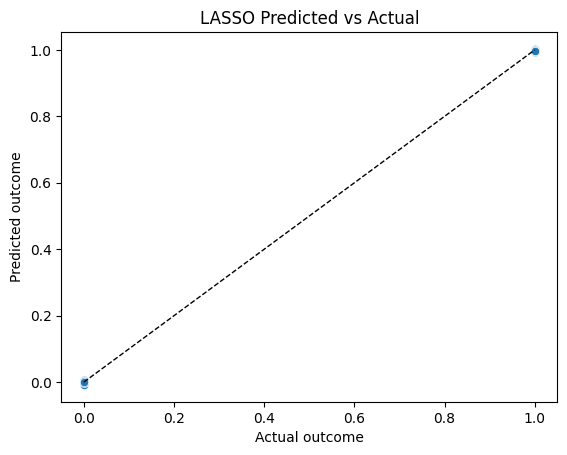

LASSO training MSE: 7.33671e-06


In [20]:
sns.scatterplot(x=y, y=y_hat_lasso)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.title('LASSO Predicted vs Actual')
plt.xlabel('Actual outcome')
plt.ylabel('Predicted outcome')
plt.show()

print(f'LASSO training MSE: {mse(y, y_hat_lasso):.6g}')

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

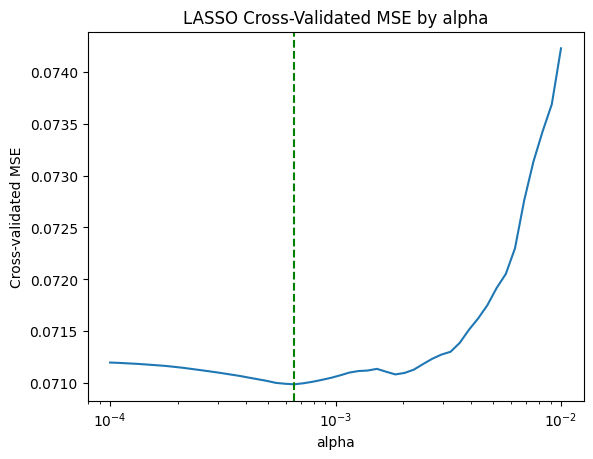

In [21]:
sns.lineplot(x=lasso_cv.alphas_, y=mean_mse_path)
plt.axvline(alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('LASSO Cross-Validated MSE by alpha')
plt.show()

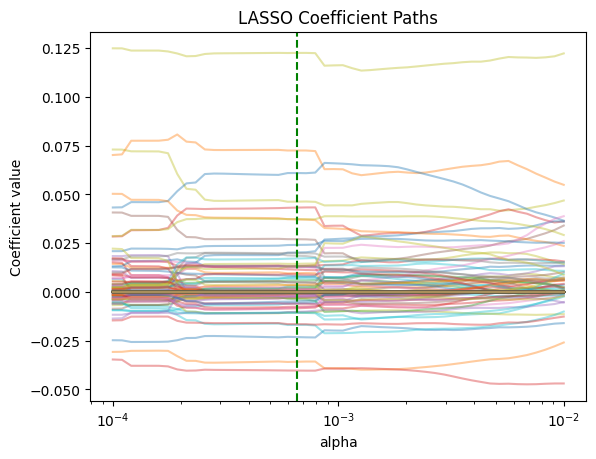

In [22]:
for i in range(coefs.shape[1]):
    plt.plot(lasso_cv.alphas_, coefs[:, i], alpha=0.4)
plt.xscale('log')
plt.axvline(alpha_star, color='green', linestyle='--')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.show()

In [23]:
print(f'Optimal alpha: {alpha_star:.10f}')

Optimal alpha: 0.0006551286


Small alpha values on the left side of the graph make the model too complex, so it is overfitting. Large alpha values on the right side of the graph produce too much shrinkage, so the model is underfitting. The right balance between bias and variance is where alpha=0.000655 because the MSE is the lowest.

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

Linear regression often performs extremely well on the training set because it minimizes the residual sum of squares using only the observed data. When there are many more predictors than observations, the model can effectively “memorize” the training data, including random noise. This leads to very low training error, but the model becomes highly sensitive to small changes in the data. As a result, it does not generalize well to new data and tends to overfit.

In contrast, the LASSO shrinks the coefficients toward zero and can set some exactly equal to zero. This prevents the model from fitting the noise in the training data and reduces its complexity. Although the LASSO may not fit the training data as closely as ordinary linear regression, it produces a model with lower variance. This tradeoff between a small increase in bias and a large reduction in variance leads to better predictive performance on new, unseen data.

7. Why do regularization methods lend themselves to scenarios like precision health?

Regularization methods like the LASSO are especially useful in precision health because these applications often involve very high-dimensional data with relatively few observations. For example, humans have between 22000 and 25000 genes that all interact in complex ways. In these settings, many predictors may be irrelevant or highly correlated, and overfitting is a major concern. Regularization helps by selecting a smaller subset of genes and interactions to focus on, which stabilizes the model. Therefore, the model is more reliable and interpretable for medical testing and research.





8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

Applying methods like the LASSO in precision health carries important risks. For one, it is important to recognize that LASSO identifies predictive relationships, not causal ones. Genes are part of a complex, interconnected system, so we cannot simply change one variable in isolation without potentially affecting many others. As a result, the features selected by the LASSO may be highly predictive of an outcome, but we cannot determine causality.

Because the model is built on correlations rather than causal identification, acting on its results can be risky. An intervention based on a selected variable might have no real effect or it could even unintentionally harm the patient. This is especially concerning in medical contexts, where decisions may involve surgery, medication, or other significant treatments.

There is also the risk that models trained on biased or unrepresentative data will produce unfair or inaccurate recommendations for certain groups. Because precision health involves making real interventions that affect people’s well-being, these limitations mean that LASSO results must be interpreted carefully and supplemented with professional knowledge and validation before being used in practice.